## **Variables correlation**

In [4]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
EEA = pd.read_csv('reduced_EEA_2023.csv')

In [6]:
EEA.head(5)

,index,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Fuel_Type,Engine_Capacity(cm3),Engine_Power(kW)
0,2,1175.0,129.0,petrol,999.0,70.0
1,3,1122.0,117.0,petrol,999.0,59.0
2,6,1588.0,126.0,diesel,1968.0,110.0
3,7,1516.0,124.0,diesel,1968.0,110.0
4,10,1349.0,126.0,petrol,1498.0,110.0


In [7]:
EEA = EEA.drop('index', axis=1)

So, we have 4 numerical values and one categorical

we should look at the distribution of our numerical features so we can know which scaler to apply

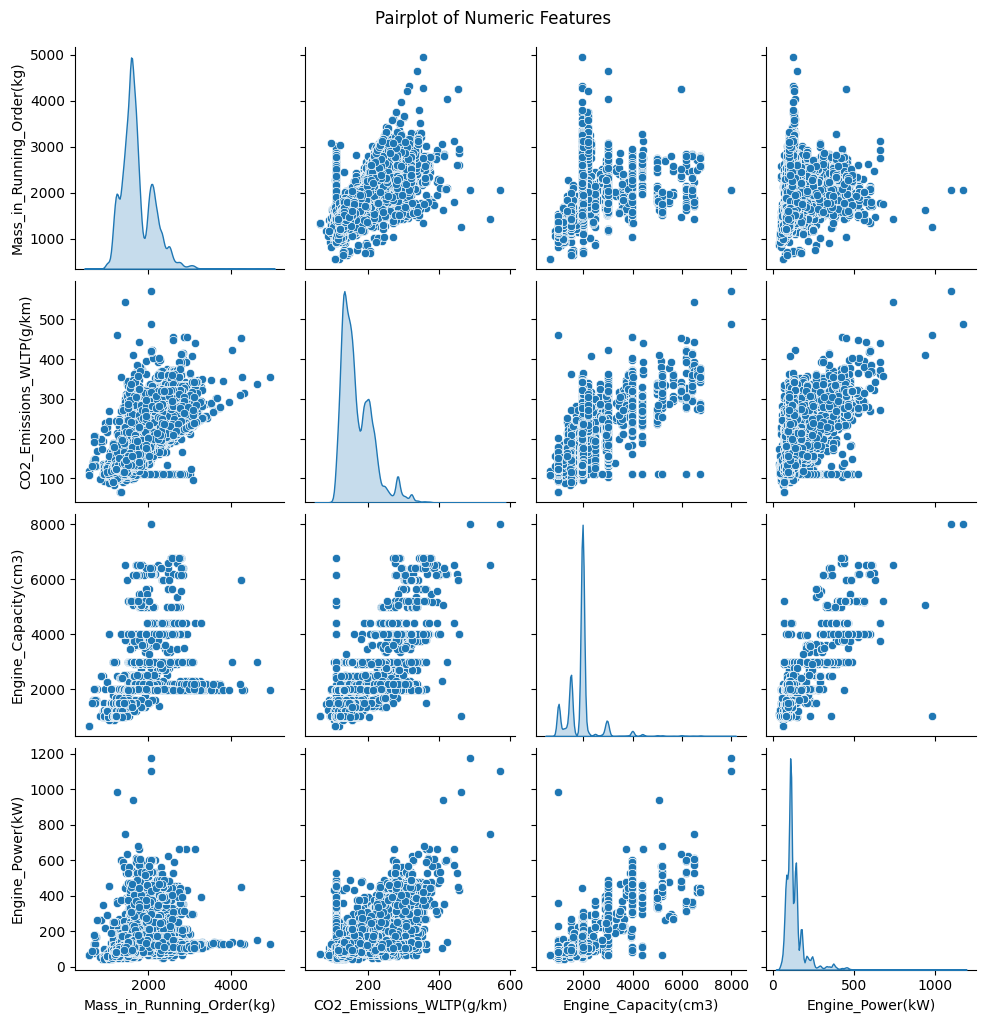

In [8]:
# Optional: Reduce number of samples if dataset is large
sns.pairplot(EEA, diag_kind='kde')
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()


Mass:
 - Distribution: Right-skewed (positive skew)
 - Observations:
    - Clustered around 1000–2000 kg
    - Long tail to heavier vehicles (>2000 kg)
    - Likely outliers in the upper range

Engine capacity: 
  - Distribution: Right-skewed, but not heavily
  - Observations:
    - Looks like it has discrete bands. This is because vehicles share the exact same engine size due to the design norms, even though it’s a continuous variable
    - Clustering around typical engine sizes (1000, 1600, 2000, 3000 cm³)
    - Gaps between these clusters — not a smooth histogram

Engine_Power(kW):
  - Distribution: Heavily right skweed
  - Observations: 
    - Most vehicles are in the 50–150 kW range
    - Extreme outliers above 300–400 kW (likely high-performance cars)
    - These outliers will influence most models

 CO2_Emissions_WLTP(g/km):
  - Distribution: Also right-skewed
  - Observations:
    - Many vehicles emit between 100–200 g/km
    - Some go well above 250–300 g/km












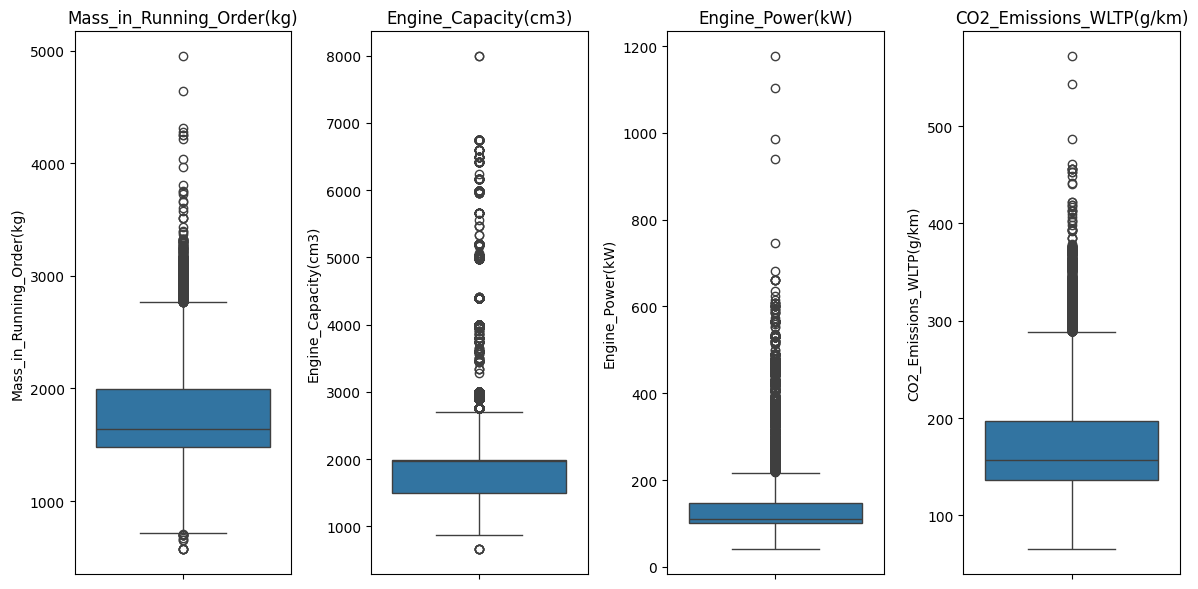

In [9]:

numeric_cols = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 
                'Engine_Power(kW)', 'CO2_Emissions_WLTP(g/km)']

plt.figure(figsize=(12, 6))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, len(numeric_cols), i)
    sns.boxplot(y=EEA[col])
    plt.title(col)
    plt.tight_layout()

plt.show()

This shows the relationship of the numeric values

how does the Fuel type distribution look like?

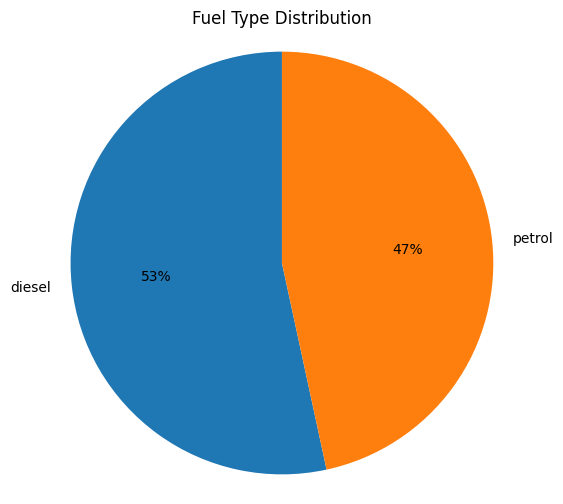

In [10]:

# Get value counts
fuel_counts = EEA['Fuel_Type'].value_counts(normalize=True)

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(fuel_counts, labels=fuel_counts.index, autopct='%1.0f%%', startangle=90)
plt.title('Fuel Type Distribution')
plt.axis('equal')  # Makes the pie chart a circle
plt.show()

Let's explore how our variables are explaining our target

## Categorical into dummies

In [11]:
EEA = pd.get_dummies(EEA, columns=['Fuel_Type'], drop_first=True)

In [13]:
EEA = EEA.astype(int)

In [14]:
EEA.head(5)

,Mass_in_Running_Order(kg),CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Fuel_Type_petrol
0,1175,129,999,70,1
1,1122,117,999,59,1
2,1588,126,1968,110,0
3,1516,124,1968,110,0
4,1349,126,1498,110,1


In [15]:
EEA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75530 entries, 0 to 75529
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Mass_in_Running_Order(kg)  75530 non-null  int64
 1   CO2_Emissions_WLTP(g/km)   75530 non-null  int64
 2   Engine_Capacity(cm3)       75530 non-null  int64
 3   Engine_Power(kW)           75530 non-null  int64
 4   Fuel_Type_petrol           75530 non-null  int64
dtypes: int64(5)
memory usage: 2.9 MB


## Model 1 - RandomForestRegressor - great results, but low interpretability

Taking onto account the skewed distributions and have a lot of outliers, we would want to use these options:
 - RandomForestRegressor
 - GradientBoostingRegressor
 - XGBoost

These models do not require scaling or normalization

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score 

# 1. Define features and target
X = EEA.drop('CO2_Emissions_WLTP(g/km)', axis=1)
y = EEA['CO2_Emissions_WLTP(g/km)']

# 2. Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Make predictions
y_pred = rf_model.predict(X_test)

# 5. Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test MSE: {mse:.2f}")
print(f"Test R² Score: {r2:.2f}")

Test MSE: 131.69
Test R² Score: 0.93


R² score of 0.93 is very good, because it means that the model can explain 93% of the data variance. The MSE of 131.69, so the RMSE is 11.47 g/km, this means that on average, your model's prediction is  around 11.5 g/km or 6% off from the true CO₂ emission value. These are quite strong indicators that the model is performing well on the test set. 

But are we overfitting? 

To be sure we have to evaluate the MSE and R2 Score and compare it with the test.

In [20]:
y_train_pred = rf_model.predict(X_train)
train_mse = mean_squared_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train MSE: {train_mse:.2f}")
print(f"Train R² Score: {train_r2:.2f}")

Train MSE: 62.32
Train R² Score: 0.97


The results are very strong, because R2 Scores from the model for both Train and Test are similar. 
The MSE in the Test is higher than the one from the Train, which is expected because model learnt in the train model

In oder to be surer about it, we could perform cross-validation

In [22]:
from sklearn.model_selection import cross_val_score


cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print(f"Cross-validated R² scores: {cv_scores}")
print(f"Mean CV R² score: {cv_scores.mean():.2f}")

Cross-validated R² scores: [0.96791303 0.9610154  0.95873973 0.88731239 0.86414979]
Mean CV R² score: 0.93


- Consistent performance: Most of the scores are above 0.95, with only two folds slightly lower (0.8873 and 0.8641). That’s a small drop, suggesting the model generalizes well.

- No severe overfitting:
    Test R² (0.93), train R² (0.97), and CV R² (0.93) are all close. This indicates that the model is neither underfitting nor overfitting.

- Robust model: The fact that CV scores stay high across folds suggests stability across different subsets of the data.

## Model 2 - Linear Regression

In [23]:
X = EEA.drop(columns='CO2_Emissions_WLTP(g/km)')
y = EEA['CO2_Emissions_WLTP(g/km)']

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_to_scale = ['Mass_in_Running_Order(kg)', 'Engine_Capacity(cm3)', 'Engine_Power(kW)']

X_scaled = X.copy()
X_scaled[features_to_scale] = scaler.fit_transform(X_scaled[features_to_scale])


In [25]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Test MSE:", mse)
print("Test R²:", r2)

Test MSE: 373.2506484468079
Test R²: 0.8111773479996278


In [26]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)
print(coefficients)

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    37.186681
3           Fuel_Type_petrol    22.820005
2           Engine_Power(kW)    10.889410
1       Engine_Capacity(cm3)     0.911440


- R² Score: 0.81
    - This means 81% of the variance in CO₂ emissions is explained by the model. That’s a strong result for a linear model, especially considering the simplicity and interpretability.

- MSE: 373.25

    - The root of Mean Squared Error is 19.3, so the model predicts around 12% off the actual value, this MSE seems reasonable.

The model generalizes well and isn't heavily overfitting.

- Mass_in_Running_Order is the Strongest predictor. Heavier vehicles emit more CO₂
- The next strongest predictor is Fuel_Type_petrol. Petrol cars emit significantly more than diesel (since "petrol = 1")
- The weakest impact is the Engine_Capacity(cm3), which indicates that might be redundant with power or mass

## Model 3 - Lasso model

In [27]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [29]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [30]:
y_pred = lasso_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Lasso Test MSE: {mse:.2f}")
print(f"Lasso Test R²: {r2:.2f}")

Lasso Test MSE: 373.32
Lasso Test R²: 0.81


In [31]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

                     Feature  Coefficient
0  Mass_in_Running_Order(kg)    36.918141
3           Fuel_Type_petrol    21.986812
2           Engine_Power(kW)    11.165629
1       Engine_Capacity(cm3)     0.662142


Best alpha: 0.0012648552168552957
Test MSE: 373.25029854558085
Test R²: 0.811177525010111


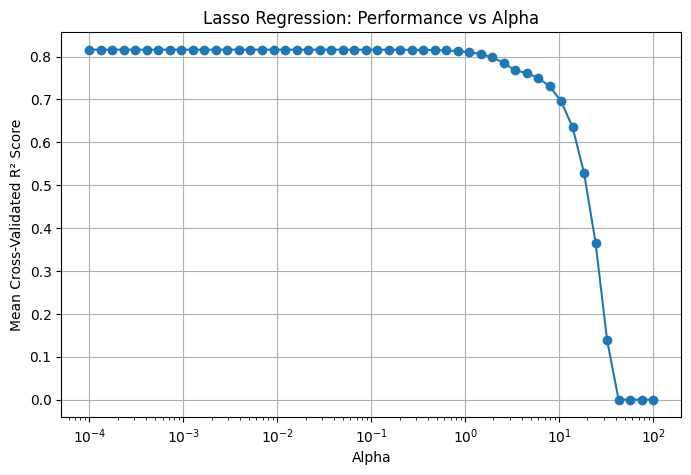

In [33]:
from sklearn.model_selection import train_test_split, GridSearchCV

# 4. Define Lasso model and alpha grid
lasso = Lasso(max_iter=10000)
alphas = {'alpha': np.logspace(-4, 2, 50)}  # alpha values from 0.0001 to 100

# 5. Grid search for best alpha
grid = GridSearchCV(lasso, alphas, cv=5, scoring='r2')
grid.fit(X_train, y_train)

# 6. Best model evaluation
best_lasso = grid.best_estimator_
y_pred = best_lasso.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Best alpha:", grid.best_params_['alpha'])
print("Test MSE:", mse)
print("Test R²:", r2)

# 7. Plot alpha vs CV R²
plt.figure(figsize=(8, 5))
plt.semilogx(alphas['alpha'], grid.cv_results_['mean_test_score'], marker='o')
plt.xlabel('Alpha')
plt.ylabel('Mean Cross-Validated R² Score')
plt.title('Lasso Regression: Performance vs Alpha')
plt.grid(True)
plt.show()